<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical_04_Naive_Bayes_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 04: Naive Bayes Classification

## Aim

To implement the Naive Bayes classification algorithm on a dataset and evaluate its performance using suitable classification metrics.

## Theory

Naive Bayes is a supervised machine learning classification algorithm based on Bayes' Theorem. It assumes that the features are conditionally independent of each other given the class label.

Bayes' Theorem is given by:

P(C|X) = [P(X|C) × P(C)] / P(X)

where:

- P(C|X) is the posterior probability of class C given the features X.
- P(X|C) is the likelihood of observing X given class C.
- P(C) is the prior probability of class C.
- P(X) is the probability of observing the features X.

For multiple features, the Naive Bayes assumption gives:

P(C|X₁, X₂, ..., Xₙ) ∝ P(C) × P(X₁|C) × P(X₂|C) × ... × P(Xₙ|C)

The class having the highest posterior probability is selected as the predicted class.

Naive Bayes is computationally efficient and works particularly well for classification problems involving high-dimensional datasets.

### Gaussian Naive Bayes

For continuous numerical features, Gaussian Naive Bayes assumes that the features follow a Gaussian (normal) distribution within each class.

The probability density function is:

P(x|C) = 1 / √(2πσ²) × exp[-(x - μ)² / (2σ²)]

where:

- μ is the mean of the feature for the class.
- σ² is the variance of the feature for the class.
- x is the observed feature value.

In this practical, Gaussian Naive Bayes will be used for classification of numerical data.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst five records:")
display(df.head())

Dataset loaded successfully!
Dataset Shape: (150, 5)

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Display dataset information

print("Dataset Information:\n")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nTarget Class Distribution:")
print(df["target"].value_counts())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Target Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [4]:
# Separate input features and target variable

X = df.drop("target", axis=1)
y = df["target"]

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

print("\nFeature Names:")
print(list(X.columns))

print("\nTarget Classes:")
print(sorted(y.unique()))

Features (X) Shape: (150, 4)
Target (y) Shape: (150,)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [5]:
# Import train-test split
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training set size: (120, 4)
Testing set size: (30, 4)

Training target distribution:
target
0    40
1    40
2    40
Name: count, dtype: int64

Testing target distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


In [6]:
# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Create the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


In [7]:
# Predict the classes for the test data

y_pred = nb_model.predict(X_test)

print("Predictions generated successfully!")

print("\nActual classes:")
print(y_test.to_numpy())

print("\nPredicted classes:")
print(y_pred)

Predictions generated successfully!

Actual classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [8]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Model Evaluation Metrics")
print("------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Model Evaluation Metrics
------------------------
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667
F1-Score  : 0.9666


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


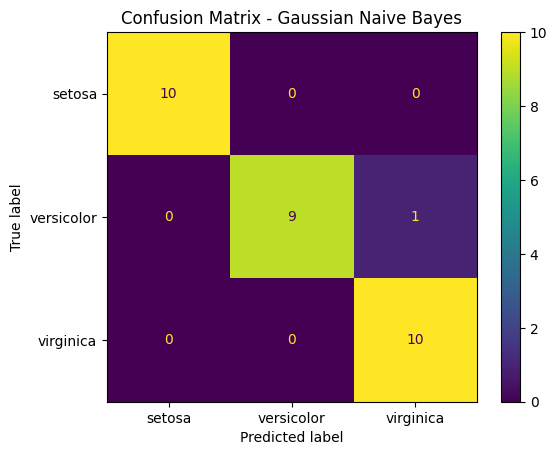

In [9]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()

In [10]:
# Generate classification report

from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Result and Conclusion

The Gaussian Naive Bayes classification algorithm was successfully implemented on the Iris dataset.

The dataset contained 150 records with 4 input features: sepal length, sepal width, petal length, and petal width. The data was divided into 80% training data and 20% testing data.

The Gaussian Naive Bayes model was trained using the training dataset and used to predict the classes of the test dataset. The model achieved approximately **96.67% accuracy**, demonstrating good classification performance.

The confusion matrix showed that all 10 Setosa samples and all 10 Virginica samples were classified correctly, while 9 out of 10 Versicolor samples were classified correctly. Only one Versicolor sample was incorrectly classified as Virginica.

Therefore, the experiment demonstrates that Gaussian Naive Bayes is an effective and computationally efficient classification algorithm for numerical datasets such as the Iris dataset.